In [53]:
!pip install -q monai

In [54]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from monai.inferers import sliding_window_inference
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_auth_token = user_secrets.get_secret("hf_auth_token")

HF_REPO = "AG2307/pengwin2026-anatomy-segmentation-model"
PELVIC_DATASET_REPO = "AG2307/pengwin-2026-anatomy-segmentation-pelvic"
FEMUR_DATASET_REPO = "AG2307/pengwin-2026-anatomy-segmentation-femur"
CHANNELS = [1, 32, 64, 128, 256, 512]
NUM_LABELS_pelvic = 4
NUM_LABELS_FEMUR = 2
PATCH_SIZE = (96, 96, 96)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [55]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv3d(
                in_channels, 
                out_channels, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                bias=False
            ),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(negative_slope=0.01, inplace=True),
            nn.Conv3d(
                out_channels, 
                out_channels, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                bias=False
            ),
            nn.InstanceNorm3d(out_channels, affine=True),
        )

        self.residual = (
            nn.Conv3d(
                in_channels, 
                out_channels, 
                kernel_size=1, 
                bias=False
            )
            if in_channels != out_channels
            else nn.Identity()
        )

        self.final_relu = nn.LeakyReLU(negative_slope=0.01, inplace=True)

    def forward(self, x):
        out = self.layers(x)
        out = out + self.residual(x)
        return self.final_relu(out)
        
class Unet(nn.Module):
    def __init__(self, channels, num_labels):
        super().__init__()
        self.encoders = nn.ModuleList([
            DoubleConv(channels[i], channels[i+1])
            for i in range(len(channels)-1)
        ])
        self.decoders = nn.ModuleList([
            DoubleConv(channels[i], channels[i-1])
            for i in range(len(channels)-1, 1, -1)
        ])
        self.reduce   = nn.ModuleList([
            nn.Conv3d(
                in_channels=channels[i],
                out_channels=channels[i-1],
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ) for i in range(len(channels)-1, 1, -1)
        ])
        self.pool     = nn.MaxPool3d(2)
        self.upsample = nn.Upsample(
            scale_factor=2,
            mode='trilinear',
            align_corners=True,
        )
        self.final_conv = nn.Conv3d(
            in_channels=channels[1],
            out_channels=num_labels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=True,
        )

    def forward(self, x):
        skips = []
        for enc in self.encoders[:-1]:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.encoders[-1](x)

        skips = list(reversed(skips))
        for i, dec in enumerate(self.decoders):
            x = self.upsample(x)
            x = self.reduce[i](x)
            x = torch.cat([x, skips[i]], dim=1)
            x = dec(x)
        x = self.final_conv(x)
        return x

In [56]:
pelvic_model = Unet(channels=CHANNELS, num_labels=NUM_LABELS_pelvic)
femur_model = Unet(channels=CHANNELS, num_labels=NUM_LABELS_FEMUR)

ckpt_path_pelvic = hf_hub_download(repo_id=HF_REPO, filename="best_model_pelvic_2.pth", repo_type="model", token = hf_auth_token)
ckpt_path_femur = hf_hub_download(repo_id=HF_REPO, filename="best_model_femur.pth", repo_type="model", token = hf_auth_token)
ckpt_pelvic = torch.load(ckpt_path_pelvic, map_location="cpu")
ckpt_femur = torch.load(ckpt_path_femur, map_location="cpu")

pelvic_model.load_state_dict(ckpt_pelvic["model_state_dict"])
pelvic_model.to(device)
pelvic_model.eval()
print(f"Loaded pelvic model from epoch {ckpt_pelvic['epoch']}, dice {ckpt_pelvic['best_dice']:.4f}")

femur_model.load_state_dict(ckpt_femur["model_state_dict"])
femur_model.to(device)
femur_model.eval()
print(f"Loaded femur model from epoch {ckpt_femur['epoch']}, dice {ckpt_femur['best_dice']:.4f}")

Loaded pelvic model from epoch 13, dice 0.9357
Loaded femur model from epoch 8, dice 0.9095


In [57]:
pelvic_val = load_dataset(PELVIC_DATASET_REPO, split="validation").with_format("torch")
femur_val = load_dataset(FEMUR_DATASET_REPO, split="validation").with_format("torch")

pelvic_val = pelvic_val.add_column("source", ["pelvic"] * len(pelvic_val))
femur_val = femur_val.add_column("source", ["femur"] * len(femur_val))

In [58]:
case_type = "pelvic"
data = ""

if case_type == "pelvic":
    data = pelvic_val
else:
    data = femur_val

In [59]:
idx = np.random.randint(len(data))
sample = data[idx]
image = sample["image"].unsqueeze(0).to(device)
label = sample["label"]
original_shape = sample['original_shape']
original_spacing = sample['original_spacing']
print(f"Showing validation case {idx}, image shape {image.shape}, original shape {original_shape}, original_spacing {original_spacing}")

Showing validation case 1, image shape torch.Size([1, 1, 301, 174, 225]), original shape tensor([  1, 345, 199, 281]), original_spacing tensor([0.8730, 0.8730, 0.8010])


In [60]:
with torch.no_grad():
    if case_type == "pelvic":
        pred = sliding_window_inference(
            inputs=image, roi_size=PATCH_SIZE, sw_batch_size=2,
            predictor=pelvic_model, overlap=0.5, mode="gaussian",
        )
    else:
        pred = sliding_window_inference(
            inputs=image, roi_size=PATCH_SIZE, sw_batch_size=2,
            predictor=femur_model, overlap=0.5, mode="gaussian",
        )
pred_hard = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

image_np = image.squeeze().cpu().numpy()
label_np = label.squeeze().cpu().numpy()

print("GT labels present:", np.unique(label_np))
print("Pred labels present:", np.unique(pred_hard))

GT labels present: [0 1 2 3]
Pred labels present: [0 1 2 3]


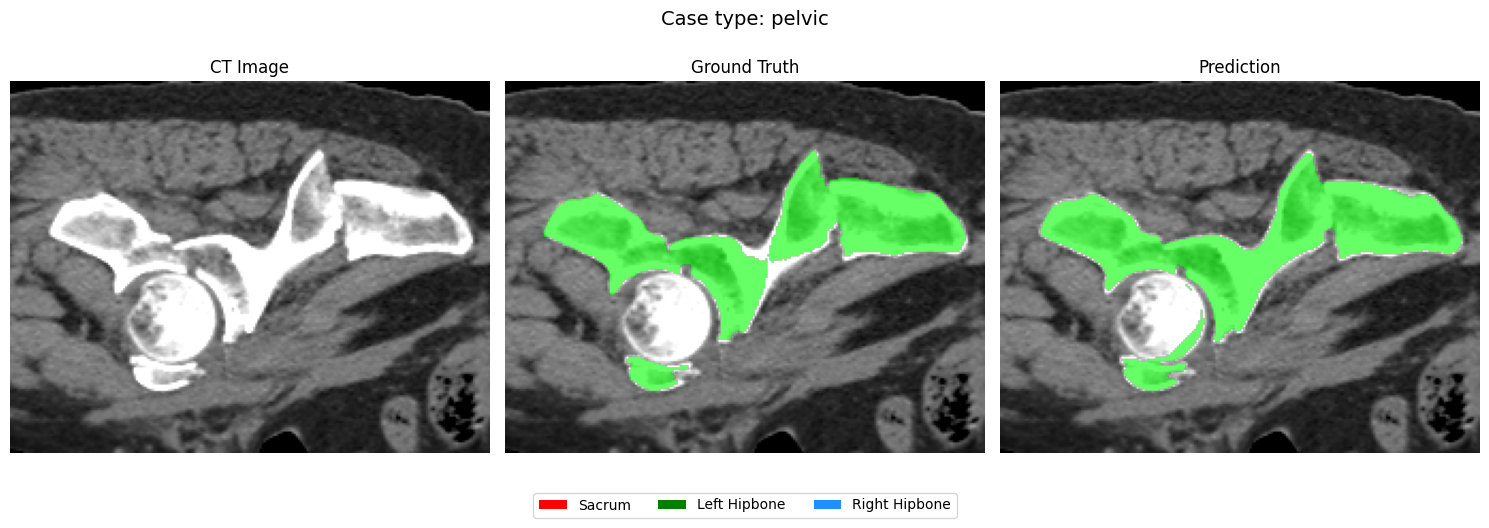

In [61]:
# define colormap + legend per case type
if case_type == "pelvic":
    # 0=background, 1=sacrum, 2=left hip, 3=right hip
    label_colors = [
        (0, 0, 0, 0),        # 0 background — transparent
        (1, 0, 0, 0.6),      # 1 sacrum — red
        (0, 1, 0, 0.6),      # 2 left hipbone — green
        (0, 0.5, 1, 0.6),    # 3 right hipbone — blue
    ]
    legend_elements = [
        Patch(facecolor="red", label="Sacrum"),
        Patch(facecolor="green", label="Left Hipbone"),
        Patch(facecolor="dodgerblue", label="Right Hipbone"),
    ]
    n_classes = 4
else:  # femur
    # 0=background, 1=femur
    label_colors = [
        (0, 0, 0, 0),        # 0 background — transparent
        (1, 1, 0, 0.6),      # 1 femur — yellow
    ]
    legend_elements = [
        Patch(facecolor="yellow", label="Femur"),
    ]
    n_classes = 2

cmap = ListedColormap(label_colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_classes + 0.5), ncolors=n_classes)

K = 4
fg_per_slice = (label_np > 0).sum(axis=(1, 2))
top_k_slices = np.argsort(fg_per_slice)[-K:]   # indices of the K slices with most foreground
best_slice = np.random.choice(top_k_slices)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_np[best_slice], cmap="gray")
axes[0].set_title("CT Image")
axes[0].axis("off")

axes[1].imshow(image_np[best_slice], cmap="gray")
axes[1].imshow(label_np[best_slice], cmap=cmap, norm=norm)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(image_np[best_slice], cmap="gray")
axes[2].imshow(pred_hard[best_slice], cmap=cmap, norm=norm)
axes[2].set_title("Prediction")
axes[2].axis("off")

fig.suptitle(f"Case type: {case_type}", fontsize=14)
fig.legend(handles=legend_elements, loc="lower center",
           ncol=len(legend_elements), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()